# Credit Risk & Loan Default Prediction
## Phase 2 — Exploratory Data Analysis (EDA)

**Goal of this notebook.** Before building any model, ask the data simple questions and see what it says. Which kinds of borrowers default more? By how much? Does it match what I saw in my year of credit investigations at Postal Savings Bank of China? A model will later *learn* these patterns automatically; EDA is how we make sure we understand them ourselves, and can explain them in plain English.

**Input.** The cleaned dataset from Phase 1 (`cs-training-clean.csv`).

**A note on rigor.** EDA here is *descriptive*: we look at patterns but do not tune anything from them. In Phase 3 we will split the data into a training set and a held-out test set, and redo the cleaning steps using training data only. Nothing we learn here is used to pick model settings.

**How to read the charts.** Almost every chart below shows the **default rate**: out of 100 borrowers in a group, how many became seriously delinquent (90+ days past due) within two years. The dashed line is the overall average (about 6.7 per 100), so bars above the line are riskier than average and bars below are safer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/cs-training-clean.csv", index_col=0)
TARGET = "SeriousDlqin2yrs"
OVERALL = df[TARGET].mean()
BLUE, RED, GREY = "#4C78A8", "#E45756", "#B0B0B0"

# Short names for the past-due columns, used only for readable charts
P30 = "NumberOfTime30-59DaysPastDueNotWorse"
P60 = "NumberOfTime60-89DaysPastDueNotWorse"
P90 = "NumberOfTimes90DaysLate"
UTIL = "RevolvingUtilizationOfUnsecuredLines"

print(f"{len(df):,} borrowers, {df.shape[1]} columns, overall default rate {OVERALL:.2%}")

149,999 borrowers, 15 columns, overall default rate 6.68%


## 1. Class balance: how many borrowers default at all?

SeriousDlqin2yrs
Did not default    139973
Defaulted           10026

Default rate: 6.68%  (about 1 borrower in 15)


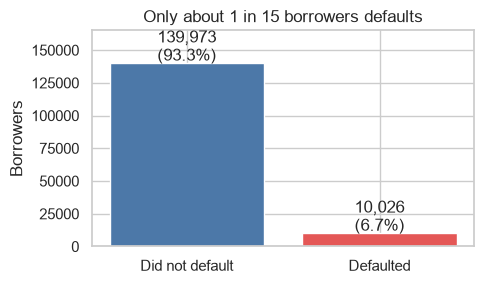

In [2]:
counts = df[TARGET].value_counts().rename({0: "Did not default", 1: "Defaulted"})
print(counts.to_string())
print(f"\nDefault rate: {OVERALL:.2%}  (about 1 borrower in {1/OVERALL:.0f})")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts.index, counts.values, color=[BLUE, RED])
for i, v in enumerate(counts.values):
    ax.text(i, v + 2000, f"{v:,}\n({v/len(df):.1%})", ha="center")
ax.set_ylim(0, 165000)
ax.set_ylabel("Borrowers")
ax.set_title("Only about 1 in 15 borrowers defaults")
plt.tight_layout()
plt.savefig("../reports/02_class_balance.png", dpi=150)
plt.show()

**Why this matters.** The target is **imbalanced**: 93% of borrowers are "good" and about 7% default. Two consequences we'll deal with later:

1. A model that says "nobody will default" is 93% accurate and has zero value. We will use metrics that reward finding the risky 7% (AUC, precision, recall), not plain accuracy.
2. We must split into train/test in a way that keeps the 7% in both halves (a *stratified* split).

## 2. What does each feature look like? (univariate distributions)

"Univariate" means one column at a time. We want to know the typical range of each feature and whether it is lopsided. Two features are shown on a log scale, because a few big values would otherwise squash the rest of the chart.

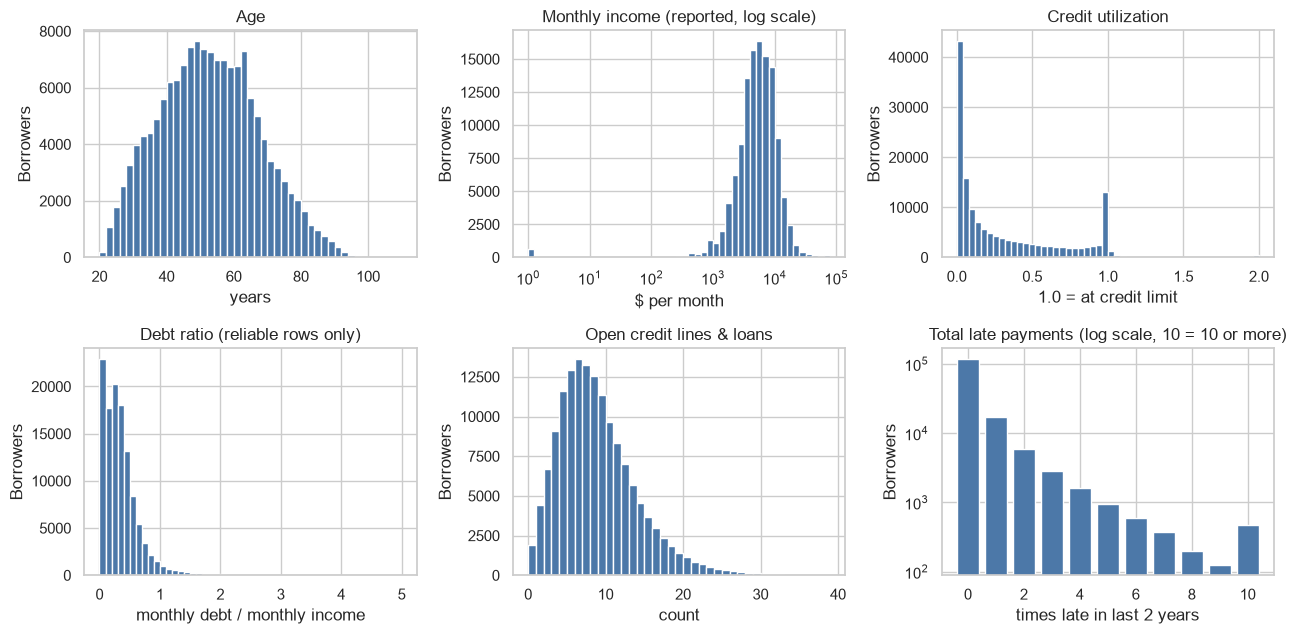

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))

axes[0, 0].hist(df.age, bins=range(20, 111, 2), color=BLUE)
axes[0, 0].set_title("Age"); axes[0, 0].set_xlabel("years")

trusted_inc = df.loc[df.income_missing_flag == 0, "MonthlyIncome"]
axes[0, 1].hist(trusted_inc, bins=np.logspace(0, np.log10(80000), 50), color=BLUE)
axes[0, 1].set_xscale("log"); axes[0, 1].set_title("Monthly income (reported, log scale)")
axes[0, 1].set_xlabel("$ per month")

axes[0, 2].hist(df[UTIL], bins=50, color=BLUE)
axes[0, 2].set_title("Credit utilization"); axes[0, 2].set_xlabel("1.0 = at credit limit")

trusted_dr = df.loc[df.debt_ratio_unreliable_flag == 0, "DebtRatio"]
axes[1, 0].hist(trusted_dr, bins=50, color=BLUE)
axes[1, 0].set_title("Debt ratio (reliable rows only)"); axes[1, 0].set_xlabel("monthly debt / monthly income")

axes[1, 1].hist(df.NumberOfOpenCreditLinesAndLoans, bins=range(0, 40), color=BLUE)
axes[1, 1].set_title("Open credit lines & loans"); axes[1, 1].set_xlabel("count")

late = df[[P30, P60, P90]].sum(axis=1).clip(upper=10).value_counts().sort_index()
axes[1, 2].bar(late.index, late.values, color=BLUE)
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Total late payments (log scale, 10 = 10 or more)")
axes[1, 2].set_xlabel("times late in last 2 years")

for a in axes.flat: a.set_ylabel("Borrowers")
plt.tight_layout()
plt.savefig("../reports/02_distributions.png", dpi=150)
plt.show()

In [4]:
summary = pd.DataFrame({
    "median age": [df.age.median()],
    "median income (reported)": [trusted_inc.median()],
    "median utilization": [df[UTIL].median()],
    "% never late": [(df[[P30, P60, P90]].sum(axis=1) == 0).mean() * 100],
    "% with 90+ day lateness": [(df[P90] > 0).mean() * 100],
}).round(1)
summary.T.rename(columns={0: "value"})

,value
median age,52.0
median income (reported),5400.0
median utilization,0.2
% never late,79.8
% with 90+ day lateness,5.6


**What this shows.**

- **Age** is spread widely, with most borrowers between their late 30s and mid 60s.
- **Income** is right-skewed: most people earn a few thousand per month and a small number earn far more, which is why we plot it on a log scale.
- **Utilization** piles up near zero (many people use little of their credit) with a second bump near 1.0 (people at their limit).
- **Late payments**: about 80% of borrowers were never late in two years. A minority have a history of lateness, and that minority is the story of this dataset (see Section 3).

## 3. Which borrowers default more? (bivariate analysis)

"Bivariate" means one feature against the target. We split borrowers into groups and compare each group's default rate. A helper function keeps the charts consistent.

In [5]:
def default_rate_by(groups, title, xlabel, ax, color=BLUE, rotate=0):
    """Bar chart of default rate per group, with the overall rate as a dashed line."""
    stats = df.groupby(groups, observed=True)[TARGET].agg(rate="mean", n="size")
    ax.bar(stats.index.astype(str), stats.rate * 100, color=color)
    ax.axhline(OVERALL * 100, color="black", ls="--", lw=1)
    for i, (r, n) in enumerate(zip(stats.rate, stats.n)):
        ax.text(i, r * 100 + 0.4, f"{r*100:.1f}%", ha="center", fontsize=9)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("Default rate (%)")
    ax.tick_params(axis="x", rotation=rotate)
    return stats

### 3a. Age

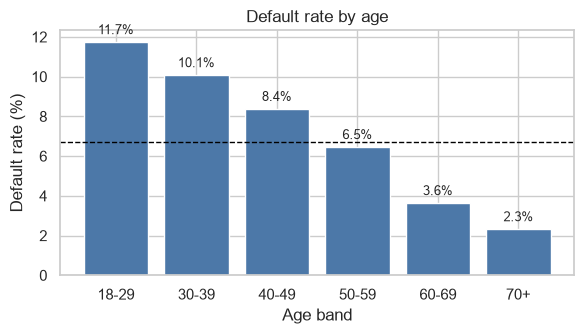

,rate,n
age,,
18-29,0.117347,8820
30-39,0.100720,23183
40-49,0.083719,34377
50-59,0.064531,35301
60-69,0.036326,28905
70+,0.023180,19413


In [6]:
age_band = pd.cut(df.age, [17, 29, 39, 49, 59, 69, 120], labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"])
fig, ax = plt.subplots(figsize=(6, 3.5))
age_stats = default_rate_by(age_band, "Default rate by age", "Age band", ax)
plt.tight_layout(); plt.savefig("../reports/02_default_by_age.png", dpi=150); plt.show()
age_stats

Default risk falls steadily with age. The 18-29 group defaults about **5 times as often** as the 70+ group (11.7% vs. 2.3%). Plausible reasons: younger borrowers have shorter credit histories, less savings, and less stable income. (This is a pattern in the data, not proof of the reason. Also note that using age in real lending decisions raises fairness and legal questions, which we come back to in Phase 6.)

### 3b. Income

Only borrowers who *reported* income are used here. The rest had income filled in by us in Phase 1, and including those guesses would blur the picture.

Income band edges ($/month): [0, 3000, 4544, 6300, 9083, 78396]


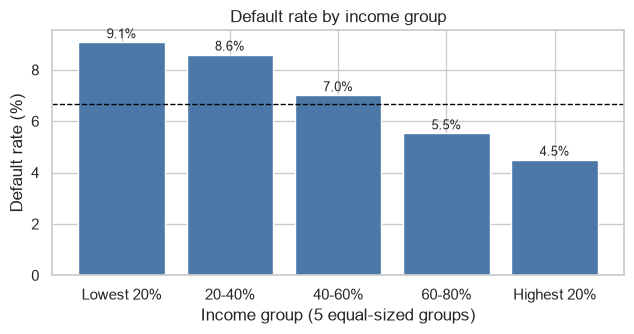

,rate,n
MonthlyIncome,,
Lowest 20%,0.090775,25084
20-40%,0.085954,23024
40-60%,0.070128,24056
60-80%,0.055306,24084
Highest 20%,0.045046,24020


In [7]:
known = df[df.income_missing_flag == 0]
income_band = pd.qcut(known.MonthlyIncome, 5, labels=["Lowest 20%", "20-40%", "40-60%", "60-80%", "Highest 20%"])
income_edges = known.MonthlyIncome.quantile([0, .2, .4, .6, .8, 1]).round(0).tolist()
print("Income band edges ($/month):", [int(e) for e in income_edges])

stats = known.groupby(income_band, observed=True)[TARGET].agg(rate="mean", n="size")
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(stats.index.astype(str), stats.rate * 100, color=BLUE)
ax.axhline(OVERALL * 100, color="black", ls="--", lw=1)
for i, r in enumerate(stats.rate):
    ax.text(i, r * 100 + 0.15, f"{r*100:.1f}%", ha="center", fontsize=9)
ax.set_title("Default rate by income group"); ax.set_xlabel("Income group (5 equal-sized groups)")
ax.set_ylabel("Default rate (%)")
plt.tight_layout(); plt.savefig("../reports/02_default_by_income.png", dpi=150); plt.show()
stats

Higher income means lower default risk, but the effect is **modest**: the lowest-income fifth defaults about twice as often as the highest-income fifth (9.1% vs. 4.5%). Income matters far less than the features that follow.

### 3c. Credit utilization

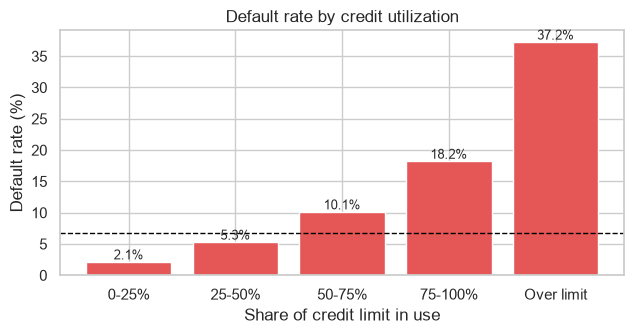

,rate,n
RevolvingUtilizationOfUnsecuredLines,,
0-25%,0.021367,87657
25-50%,0.052909,21055
50-75%,0.101279,13764
75-100%,0.182134,24202
Over limit,0.372478,3321


In [8]:
util_band = pd.cut(df[UTIL], [-0.001, .25, .5, .75, 1.0, 2.0],
                   labels=["0-25%", "25-50%", "50-75%", "75-100%", "Over limit"])
fig, ax = plt.subplots(figsize=(6.5, 3.5))
util_stats = default_rate_by(util_band, "Default rate by credit utilization", "Share of credit limit in use", ax, color=RED)
plt.tight_layout(); plt.savefig("../reports/02_default_by_utilization.png", dpi=150); plt.show()
util_stats

Utilization has a **steep, steady climb**. Borrowers using under a quarter of their limit default only 2.1% of the time; borrowers over their limit default **37%** of the time, about 17 times as often. People who lean heavily on credit are often already under financial strain.

### 3d. Payment history: the strongest signal so far

Now the three "times late" columns. We show 0, 1, 2, 3 and "4 or more" times.

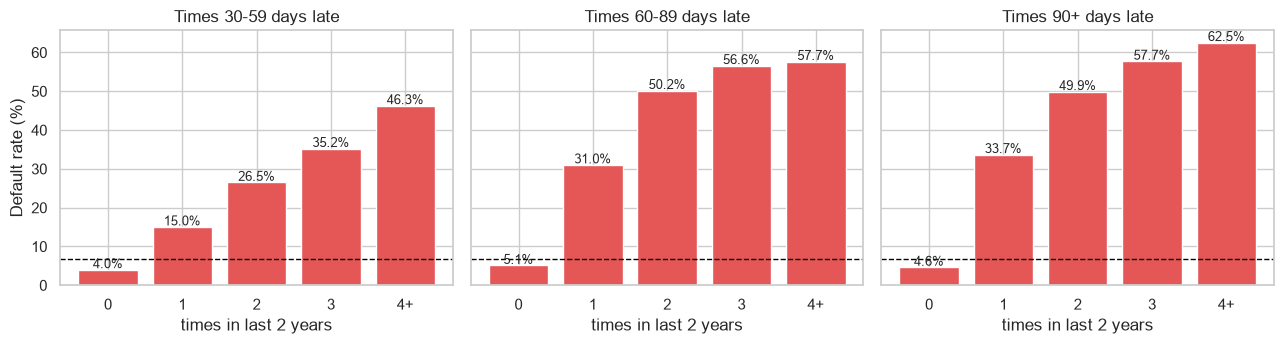

,30-59 days late,60-89 days late,90+ days late
0,0.040,0.051,0.046
1,0.150,0.310,0.337
2,0.265,0.502,0.499
3,0.352,0.566,0.577
4+,0.463,0.577,0.625


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
past_stats = {}
for ax, col, name in zip(axes, [P30, P60, P90], ["30-59 days late", "60-89 days late", "90+ days late"]):
    grp = df[col].clip(upper=4).map({0: "0", 1: "1", 2: "2", 3: "3", 4: "4+"})
    past_stats[name] = default_rate_by(grp, f"Times {name}", "times in last 2 years", ax, color=RED)
axes[0].set_ylabel("Default rate (%)")
for a in axes[1:]: a.set_ylabel("")
plt.tight_layout(); plt.savefig("../reports/02_default_by_past_due.png", dpi=150); plt.show()
pd.concat({k: v.rate.round(3) for k, v in past_stats.items()}, axis=1)

In [10]:
df["ever_late"] = (df[[P30, P60, P90]].sum(axis=1) > 0)
ever = df.groupby("ever_late")[TARGET].agg(default_rate="mean", borrowers="size")
ever.index = ["Never late in 2 years", "Late at least once"]
ever.round(3)

,default_rate,borrowers
Never late in 2 years,0.027,119637
Late at least once,0.223,30362


**This is the clearest pattern in the whole dataset.** A borrower who has been 90+ days late even *once* defaults about **34%** of the time, versus 4.6% for someone who never has (a ~7x jump). Someone late at least once (any of the three categories) defaults **22%** of the time, versus **2.7%** for someone never late: **about 8 times** the risk. Past behavior predicts future behavior.

This matches how I approached credit investigations at the bank: repayment history is the first thing you look at.

### 3e. Debt ratio, and a few smaller features

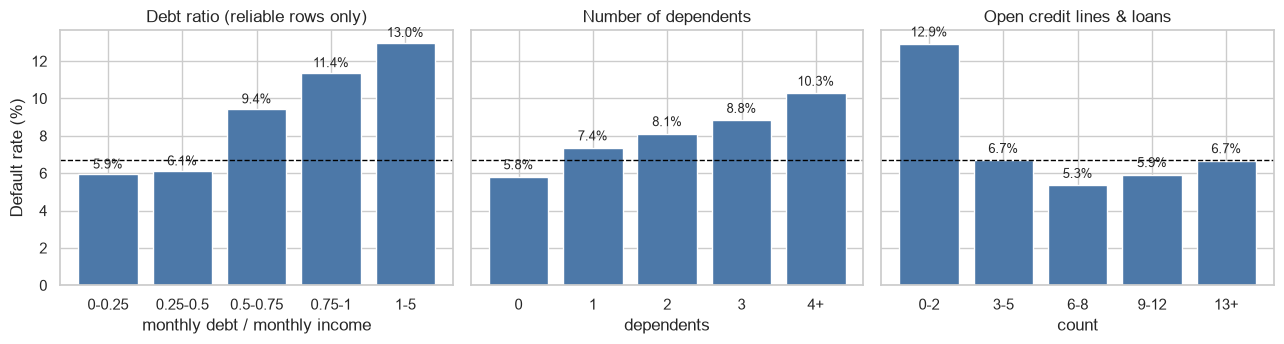

Debt ratio groups:
            rate      n
DebtRatio              
0-0.25     0.059  50739
0.25-0.5   0.061  41346
0.5-0.75   0.094  15728
0.75-1     0.114   5222
1-5        0.130   4881


In [11]:
trusted = df[df.debt_ratio_unreliable_flag == 0]
dr_band = pd.cut(trusted.DebtRatio, [-0.001, .25, .5, .75, 1, 5], labels=["0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1", "1-5"])
dr_stats = trusted.groupby(dr_band, observed=True)[TARGET].agg(rate="mean", n="size")

dep = df.NumberOfDependents.clip(upper=4).astype(int).map({0: "0", 1: "1", 2: "2", 3: "3", 4: "4+"})
lines = pd.cut(df.NumberOfOpenCreditLinesAndLoans, [-1, 2, 5, 8, 12, 60], labels=["0-2", "3-5", "6-8", "9-12", "13+"])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
axes[0].bar(dr_stats.index.astype(str), dr_stats.rate * 100, color=BLUE)
axes[0].axhline(OVERALL * 100, color="black", ls="--", lw=1)
for i, r in enumerate(dr_stats.rate): axes[0].text(i, r*100 + 0.3, f"{r*100:.1f}%", ha="center", fontsize=9)
axes[0].set_title("Debt ratio (reliable rows only)"); axes[0].set_xlabel("monthly debt / monthly income")
axes[0].set_ylabel("Default rate (%)")
dep_stats = default_rate_by(dep, "Number of dependents", "dependents", axes[1])
line_stats = default_rate_by(lines, "Open credit lines & loans", "count", axes[2])
axes[1].set_ylabel(""); axes[2].set_ylabel("")
plt.tight_layout(); plt.savefig("../reports/02_default_by_other.png", dpi=150); plt.show()
print("Debt ratio groups:"); print(dr_stats.round(3))

- **Debt ratio** (among the rows where it is reliable): risk rises from about 6% to 13% as debts approach and exceed income. This is a real signal, but much weaker than payment history or utilization.
- **Dependents**: risk creeps up with the number of dependents (5.8% with none, 10.3% with four or more): more people to support, less financial slack.
- **Open credit lines**: the relationship is shallow and not a straight line. Borrowers with very few lines (0-2) have the highest default rate (12.9%, versus 5-7% for everyone else), which may reflect thin credit files.

## 4. How do the features relate to each other? (correlation heatmap)

A **correlation** between two columns measures how much they move together, from -1 (opposite) to +1 (in lockstep), with 0 meaning no relationship. We use *Spearman* correlation, which looks at ranking rather than exact values, so a few extreme numbers cannot distort it. We leave out the flag columns from Phase 1 to keep the picture readable.

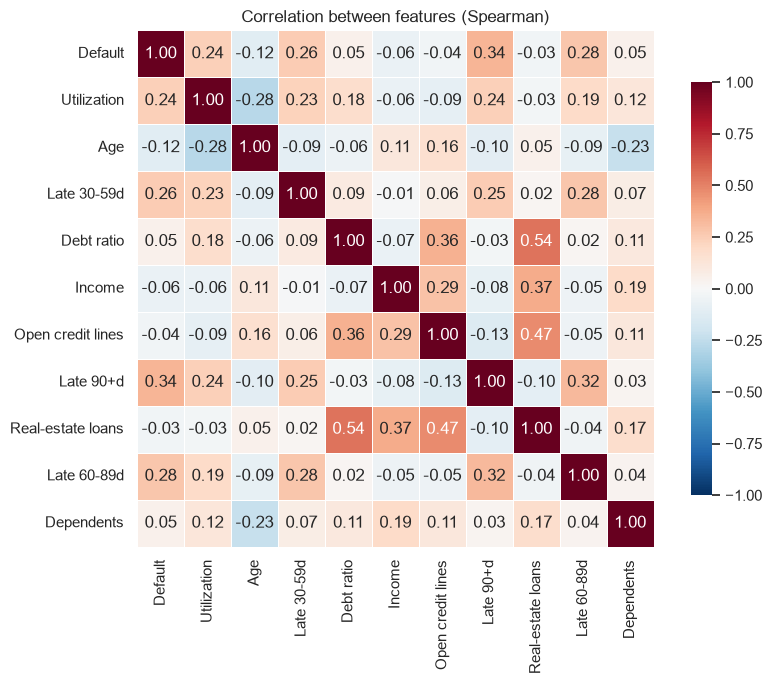

In [12]:
short = {
    TARGET: "Default", UTIL: "Utilization", "age": "Age", P30: "Late 30-59d", "DebtRatio": "Debt ratio",
    "MonthlyIncome": "Income", "NumberOfOpenCreditLinesAndLoans": "Open credit lines", P90: "Late 90+d",
    "NumberRealEstateLoansOrLines": "Real-estate loans", P60: "Late 60-89d", "NumberOfDependents": "Dependents",
}
corr = df[list(short)].rename(columns=short).corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation between features (Spearman)")
plt.tight_layout(); plt.savefig("../reports/02_correlation_heatmap.png", dpi=150); plt.show()

In [13]:
print("Correlation with default, strongest first:")
print(corr["Default"].drop("Default").sort_values(key=abs, ascending=False).round(2).to_string())
print()
print("Correlation among the three late-payment columns:")
print(corr.loc[["Late 30-59d", "Late 60-89d", "Late 90+d"], ["Late 30-59d", "Late 60-89d", "Late 90+d"]].round(2).to_string())

Correlation with default, strongest first:
Late 90+d            0.34
Late 60-89d          0.28
Late 30-59d          0.26
Utilization          0.24
Age                 -0.12
Income              -0.06
Debt ratio           0.05
Dependents           0.05
Open credit lines   -0.04
Real-estate loans   -0.03

Correlation among the three late-payment columns:
             Late 30-59d  Late 60-89d  Late 90+d
Late 30-59d         1.00         0.28       0.25
Late 60-89d         0.28         1.00       0.32
Late 90+d           0.25         0.32       1.00


**What this shows.**

- The features most tied to default are the **late-payment counts and utilization**. Age is next (negative: older means safer). Income, debt ratio and the credit-line counts are only weakly related.
- The three **late-payment columns are moderately correlated with each other** (about 0.25-0.32): someone who is 30-59 days late is somewhat more likely to also appear in the 60-89 or 90+ day columns. They overlap but are not identical. When features overlap this way it is called *multicollinearity*; it can make individual coefficients in logistic regression less stable, and it is one reason to consider a combined "total late payments" feature in Phase 3.
- **Open credit lines** and **real-estate loans** are correlated (having a mortgage is one kind of credit line), which is expected.

## 5. Key takeaways (plain business language)

1. **Payment history dominates.** Borrowers who have been 90+ days late even once default about 34% of the time; those who have never been late default under 3% of the time. Prior lateness is the strongest warning sign in the data.
2. **Heavy credit use is a strong red flag.** Default risk rises steadily with the share of credit limit in use, from about 2% (under 25% used) to 37% (over the limit): a 17-fold difference.
3. **Younger borrowers are riskier.** The 18-29 group defaults about 5 times as often as those over 70 (11.7% vs. 2.3%). This is useful for a model but sensitive in real lending, because of fairness and regulation.
4. **Income matters, but less than behavior.** The lowest-income fifth defaults about twice as often as the highest (9.1% vs. 4.5%); how someone has *behaved* with credit predicts far more than how much they earn.
5. **Defaults are rare (about 6.7%)**, so accuracy is a misleading score. We'll judge models on how well they rank risky borrowers above safe ones (AUC), and on precision and recall.

**Connection to my bank experience.** These findings line up with the instincts of a credit officer: check repayment history first, then how stretched the borrower already is. What the data adds is *how much* each factor matters, in numbers. In Phase 4 we'll see whether a model can beat a simple rule like "flag anyone who has ever been late".

### Caveats
- These are **associations, not causes**. Utilization being high may be a *symptom* of financial trouble, not the cause of default.
- The late-payment columns describe the past, but the outcome is defined as 90+ days late in the next two years. A borrower already 90+ days late is likely to stay in that state, so prediction from these columns may be partly "continuing existing trouble". This is worth keeping in mind when interpreting the model.